In [124]:
!pip install gurobipy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\simor\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 2 – Model extensions on the 100 bricks / 10 SRs instance


### 2.1 100 bricks / 10 SRs – computing the non‑dominated set (integral assignments)

In this section we:
- load the 100×10 instance from the Excel file,
- rebuild the distance matrix and the current territories from the raw data,
- reuse the same workload‑balance constraints as in Step 1,
- compute the non‑dominated set for the bi‑objective problem  
  (minimize distance, minimize disruption) using an ε‑constraint scheme.


Total workload after scaling: 10.0000 (target = 10)
Office indices (0‑based): [2, 17, 29, 32, 58, 65, 72, 78, 81, 97]
Distance matrix shape (SRs × bricks): (10, 100)

=== 2.1 100 bricks / 10 SRs – integral assignments (x ∈ {0,1}) ===
Disruption at minimal distance: 4.8015
Minimal achievable disruption: 0.3427
ε-grid: [0.3427 0.4427 0.5427 0.6427 0.7427 0.8427 0.9427 1.0427 1.1427 1.2427
 1.3427 1.4427 1.5427 1.6427 1.7427 1.8427 1.9427 2.0427 2.1427 2.2427
 2.3427 2.4427 2.5427 2.6427 2.7427 2.8427 2.9427 3.0427 3.1427 3.2427
 3.3427 3.4427 3.5427 3.6427 3.7427 3.8427 3.9427 4.0427 4.1427 4.2427
 4.3427 4.4427 4.5427 4.6427 4.7427]
ε = 0.3427  →  distance = 27.379, disruption = 0.3427
ε = 0.4427  →  distance = 25.301, disruption = 0.4287
ε = 0.5427  →  distance = 24.276, disruption = 0.5360
ε = 0.6427  →  distance = 23.738, disruption = 0.6354
ε = 0.7427  →  distance = 23.098, disruption = 0.7386
ε = 0.8427  →  distance = 22.515, disruption = 0.8396
ε = 0.9427  →  distance = 22.082, di

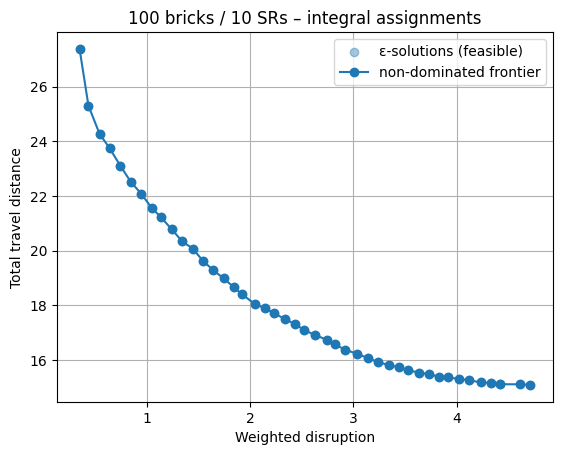

In [125]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from gurobipy import Model, GRB

# ---------------------------------------------------------------------------
# Data loading and preprocessing
# ---------------------------------------------------------------------------

CURRENT_DIR = Path.cwd()
DATA_PATH = CURRENT_DIR / "data-100x10.xlsx"

# The Excel file contains, for each brick:
#  - x, y       : geographical coordinates
#  - index      : workload index
#  - current    : id of the currently responsible SR
#  - office     : 1 if the brick hosts an SR office, 0 otherwise
df = pd.read_excel(
    DATA_PATH,
    header=None,
    usecols="A:E",
    nrows=100
)
df.columns = ["x", "y", "index", "current", "office"]

Bricks = len(df)

# Number of sales reps = number of offices in the file
Sales = int(df["office"].sum())

# Raw workload indices from the file
workloads_raw = df["index"].to_numpy(dtype=float)

# In the original 4×22 instance, the sum of the indices was equal to the
# number of SRs. We keep the same convention here by rescaling the indices
# so that the total workload equals the number of SRs.
scale = Sales / workloads_raw.sum()
workloads = workloads_raw * scale
print(f"Total workload after scaling: {workloads.sum():.4f} (target = {Sales})")

# Coordinates of all bricks
coords = df[["x", "y"]].to_numpy(dtype=float)

# Indices of bricks that host an SR office (0-based)
office_indices = df.index[df["office"] == 1].to_list()
assert len(office_indices) == Sales, "Office count must match the number of SRs"
print(f"Office indices (0‑based): {office_indices}")

# Distance[j, i] = distance between office of SR j and brick i.
# We build SR j in the same order as office_indices.
Distance = np.vstack([
    np.linalg.norm(coords - coords[office_idx], axis=1)
    for office_idx in office_indices
])
print("Distance matrix shape (SRs × bricks):", Distance.shape)

# Initial (current) assignment matrix:
#   SR_initial[j, i] = 1 if brick i currently belongs to SR j, 0 otherwise.
SR_initial = np.zeros((Sales, Bricks), dtype=int)
for i in range(Bricks):
    sr = int(df.loc[i, "current"]) - 1  # data is 1‑based
    if 0 <= sr < Sales:
        SR_initial[sr, i] = 1

# Workload bounds as in the project statement
WORKLOAD_BOUNDS = (0.8, 1.2)


# ---------------------------------------------------------------------------
# Model builder
# ---------------------------------------------------------------------------

def build_assignment_model(
    vtype=GRB.BINARY,
    workloads=workloads,
    distance=Distance,
    initial_assignment=SR_initial,
    workload_bounds=WORKLOAD_BOUNDS,
    model_name="Pfizer_100x10",
):
    """Build a Gurobi model for the assignment problem.

    Parameters
    ----------
    vtype : gurobipy constant
        GRB.BINARY (default) for integral assignments or GRB.CONTINUOUS
        for partial assignments.
    workloads : np.ndarray
        Workload index of each brick (length = number of bricks).
    distance : np.ndarray
        Matrix of shape (Sales, Bricks) with travel distances.
    initial_assignment : np.ndarray
        0/1 matrix of shape (Sales, Bricks) describing the current territories.
    workload_bounds : (float, float)
        Lower and upper bounds on each SR's workload.
    model_name : str
        Name of the Gurobi model.

    Returns
    -------
    m : gurobipy.Model
    x : gurobipy.tupledict
        Decision variables x[j, i] (fraction of brick i assigned to SR j).
    distance_expr : gurobipy.LinExpr
        Expression for the total traveled distance.
    disruption_expr : gurobipy.LinExpr
        Expression for the (workload‑weighted) disruption.
    """
    m = Model(model_name)
    m.Params.OutputFlag = 0  # keep the log clean

    sales, bricks = distance.shape

    # x[j, i] is the fraction of brick i served by SR j.
    x = m.addVars(sales, bricks, vtype=vtype, name="x")

    # (1) Coverage: each brick must be entirely covered
    for i in range(bricks):
        m.addConstr(sum(x[j, i] for j in range(sales)) == 1.0, name=f"assign_{i}")

    # (2) Workload balance: each SR workload in [min_w, max_w]
    min_w, max_w = workload_bounds
    for j in range(sales):
        load = sum(x[j, i] * workloads[i] for i in range(bricks))
        m.addConstr(load >= min_w, name=f"load_min_{j}")
        m.addConstr(load <= max_w, name=f"load_max_{j}")

    # (3) Total distance
    distance_expr = sum(
        distance[j, i] * x[j, i] for j in range(sales) for i in range(bricks)
    )

    # (4) Disruption, weighted by workload:
    #     if a brick changes SR, we incur its workload as disruption.
    disruption_expr = sum(
        0.5
        * (initial_assignment[j, i] - 2 * initial_assignment[j, i] * x[j, i] + x[j, i])
        * workloads[i]
        for j in range(sales)
        for i in range(bricks)
    )

    return m, x, distance_expr, disruption_expr


# ---------------------------------------------------------------------------
# ε‑constraint scheme (distance as main objective, disruption constrained)
# ---------------------------------------------------------------------------

def epsilon_pareto(vtype=GRB.BINARY):
    """Compute Pareto points with an ε‑constraint on the disruption.

    The function returns a list of (disruption, distance) points.
    """
    # 1) Distance‑only solution
    m_dist, _, dist_expr_dist, disr_expr_dist = build_assignment_model(vtype=vtype)
    m_dist.setObjective(dist_expr_dist, GRB.MINIMIZE)
    m_dist.optimize()
    if m_dist.status != GRB.OPTIMAL:
        raise RuntimeError("Distance‑only model is infeasible.")
    disr_at_min_dist = disr_expr_dist.getValue()
    print(f"Disruption at minimal distance: {disr_at_min_dist:.4f}")

    # 2) Disruption‑only solution
    m_disr, _, _, disr_expr_disr = build_assignment_model(vtype=vtype)
    m_disr.setObjective(disr_expr_disr, GRB.MINIMIZE)
    m_disr.optimize()
    if m_disr.status != GRB.OPTIMAL:
        raise RuntimeError("Disruption‑only model is infeasible.")
    disr_min = disr_expr_disr.getValue()
    print(f"Minimal achievable disruption: {disr_min:.4f}")

    lo, hi = sorted((disr_min, disr_at_min_dist))
    epsilon_step = 0.1   # Step of 0.1
    epsilons = np.arange(lo, hi + 1e-9, epsilon_step)
    print("ε-grid:", np.round(epsilons, 4))


    pareto = []
    for eps in epsilons:
        m, _, dist_expr, disr_expr = build_assignment_model(vtype=vtype)
        # ε‑constraint on disruption
        m.addConstr(disr_expr <= float(eps) + 1e-6, name="eps_disruption")
        m.setObjective(dist_expr, GRB.MINIMIZE)
        m.optimize()

        if m.status == GRB.OPTIMAL:
            d = dist_expr.getValue()
            r = disr_expr.getValue()
            pareto.append((r, d))
            print(f"ε = {eps:.4f}  →  distance = {d:.3f}, disruption = {r:.4f}")
        else:
            print(f"ε = {eps:.4f}  →  infeasible")

    return pareto


def non_dominated(points, tol=1e-6):
    """Extract non‑dominated points from a list of (disruption, distance)."""
    pts = sorted(points, key=lambda p: (p[0], p[1]))  # sort by disruption then distance
    nd = []
    best_dist = float("inf")
    for disr, dist in pts:
        if dist < best_dist - tol:
            nd.append((disr, dist))
            best_dist = dist
    return nd


# ---------------------------------------------------------------------------
# 2.1 – 100 bricks / 10 SRs with integral assignments
# ---------------------------------------------------------------------------

print("\n=== 2.1 100 bricks / 10 SRs – integral assignments (x ∈ {0,1}) ===")
pareto_int = epsilon_pareto(vtype=GRB.BINARY)
nd_int = non_dominated(pareto_int)

if nd_int:
    disr_all, dist_all = zip(*pareto_int)
    disr_nd, dist_nd = zip(*nd_int)

    plt.figure()
    plt.scatter(disr_all, dist_all, alpha=0.4, label="ε‑solutions (feasible)")
    plt.plot(disr_nd, dist_nd, "o-", label="non‑dominated frontier")
    plt.xlabel("Weighted disruption")
    plt.ylabel("Total travel distance")
    plt.title("100 bricks / 10 SRs – integral assignments")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No Pareto points found for the integral model.")



=== 2.1 100 bricks / 10 SRs – maps of extreme solutions ===
Min distance : 15.037, disruption = 4.8015
Min disruption (Pareto-extreme) : Δ=0.3427, D=27.379


C:\Users\simor\AppData\Local\Temp\ipykernel_22444\4270525536.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", sales)


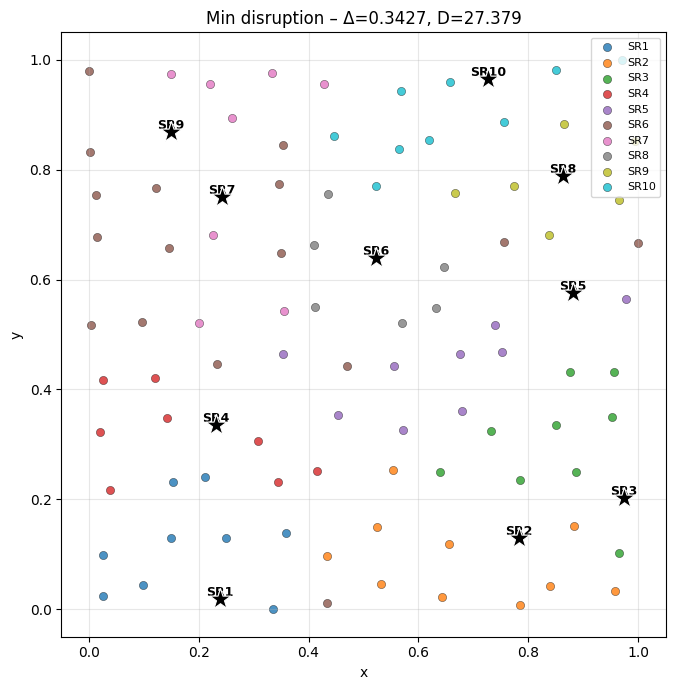

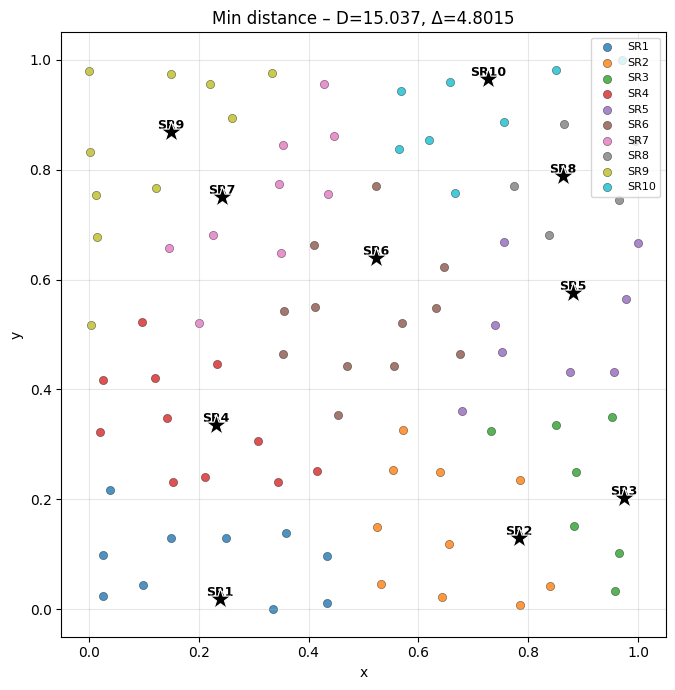

In [126]:
from gurobipy import Model, GRB, quicksum
import numpy as np
import matplotlib.pyplot as plt


############################################################################
# Helpers to extract and plot assignments
############################################################################

def extract_assignment(x_vars, sales, bricks):
    """
    Transform x[j,i] variables into a vector of assignments:
    assign[i] = j* (index of SR serving brick i).
    """
    assign = np.zeros(bricks, dtype=int)
    for i in range(bricks):
        vals = [x_vars[j, i].X for j in range(sales)]
        assign[i] = int(np.argmax(vals))   # SR index 0..sales-1
    return assign


def plot_assignment_map(title, assignment, coords, office_indices):
    """
    Plot a map of bricks colored by SR + stars for offices.

    - assignment[i] ∈ {0, ..., Sales-1}
    - coords[i] = (x_i, y_i)
    - office_indices[j] = index of the brick hosting SR j's office
    """
    sales = len(office_indices)
    bricks = coords.shape[0]
    cmap = plt.cm.get_cmap("tab10", sales)

    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    # Bricks colored by SR
    for j in range(sales):
        mask = (assignment == j)
        if not np.any(mask):
            continue
        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=35,
            color=cmap(j),
            label=f"SR{j+1}",
            alpha=0.8,
            edgecolors="k",
            linewidths=0.3,
        )

    # Offices marked with black stars
    for j in range(sales):
        idx = office_indices[j]
        x_off, y_off = coords[idx, 0], coords[idx, 1]
        plt.scatter(
            x_off, y_off,
            marker="*",
            s=250,
            color="black",
            edgecolors="white",
            linewidths=0.8,
            zorder=5,
        )
        plt.text(
            x_off, y_off,
            f"SR{j+1}",
            fontsize=9,
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_aspect("equal", "box")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


############################################################################
# 2.1 – Map of the two extreme solutions (min distance / min disruption)
############################################################################

print("\n=== 2.1 100 bricks / 10 SRs – maps of extreme solutions ===")

# (A) Min distance solution
m_dist, x_dist, dist_expr_dist, disr_expr_dist = build_assignment_model(vtype=GRB.BINARY)
m_dist.setObjective(dist_expr_dist, GRB.MINIMIZE)
m_dist.optimize()
if m_dist.status != GRB.OPTIMAL:
    raise RuntimeError("Distance-only model infeasible.")

distance_min = dist_expr_dist.getValue()
disruption_at_distance_min = disr_expr_dist.getValue()
assign_distance = extract_assignment(x_dist, Sales, Bricks)

print(f"Min distance : {distance_min:.3f}, disruption = {disruption_at_distance_min:.4f}")

# (B) Min disruption solution on the Pareto frontier:
#     first find the minimal disruption, then among those
#     solutions choose the one with minimal distance.

# 1) Find minimal disruption value
m_disr0, _, _, disr_expr_disr0 = build_assignment_model(vtype=GRB.BINARY)
m_disr0.setObjective(disr_expr_disr0, GRB.MINIMIZE)
m_disr0.optimize()
if m_disr0.status != GRB.OPTIMAL:
    raise RuntimeError("Disruption-only model infeasible.")

disr_min = disr_expr_disr0.getValue()

# 2) Now minimize distance subject to disruption <= disr_min
m_disr, x_disr, dist_expr_disr, disr_expr_disr = build_assignment_model(vtype=GRB.BINARY)
m_disr.addConstr(disr_expr_disr <= disr_min + 1e-6, name="fix_min_disruption")
m_disr.setObjective(dist_expr_disr, GRB.MINIMIZE)
m_disr.optimize()
if m_disr.status != GRB.OPTIMAL:
    raise RuntimeError("Min-distance-at-min-disruption model infeasible.")

disruption_min = disr_expr_disr.getValue()
distance_at_disruption_min = dist_expr_disr.getValue()
assign_disruption = extract_assignment(x_disr, Sales, Bricks)

print(f"Min disruption (Pareto-extreme) : Δ={disruption_min:.4f}, D={distance_at_disruption_min:.3f}")


# (C) Plot maps only (no Pareto frontier here)

plot_assignment_map(
    title=f"Min disruption – Δ={disruption_min:.4f}, D={distance_at_disruption_min:.3f}",
    assignment=assign_disruption,
    coords=coords,
    office_indices=office_indices,
)

plot_assignment_map(
    title=f"Min distance – D={distance_min:.3f}, Δ={disruption_at_distance_min:.4f}",
    assignment=assign_distance,
    coords=coords,
    office_indices=office_indices,
)



### 2.2 Allowing partial assignment of bricks

We now relax the integrality constraints and allow each brick to be **split between several SRs**
(i.e., the variables become continuous in \([0,1]\)).  
The model is exactly the same as above; only the variable type changes.
We then compare the Pareto front with the integral case.



=== 2.2 100 bricks / 10 SRs – partial assignments allowed (x ∈ [0,1]) ===
Disruption at minimal distance: 5.0104
Minimal achievable disruption: 0.3426
ε-grid: [0.3426 0.4426 0.5426 0.6426 0.7426 0.8426 0.9426 1.0426 1.1426 1.2426
 1.3426 1.4426 1.5426 1.6426 1.7426 1.8426 1.9426 2.0426 2.1426 2.2426
 2.3426 2.4426 2.5426 2.6426 2.7426 2.8426 2.9426 3.0426 3.1426 3.2426
 3.3426 3.4426 3.5426 3.6426 3.7426 3.8426 3.9426 4.0426 4.1426 4.2426
 4.3426 4.4426 4.5426 4.6426 4.7426 4.8426 4.9426]
ε = 0.3426  →  distance = 26.645, disruption = 0.3426
ε = 0.4426  →  distance = 24.910, disruption = 0.4426
ε = 0.5426  →  distance = 24.029, disruption = 0.5426
ε = 0.6426  →  distance = 23.420, disruption = 0.6426
ε = 0.7426  →  distance = 22.904, disruption = 0.7426
ε = 0.8426  →  distance = 22.425, disruption = 0.8426
ε = 0.9426  →  distance = 21.960, disruption = 0.9426
ε = 1.0426  →  distance = 21.502, disruption = 1.0426
ε = 1.1426  →  distance = 21.077, disruption = 1.1426
ε = 1.2426  →  dist

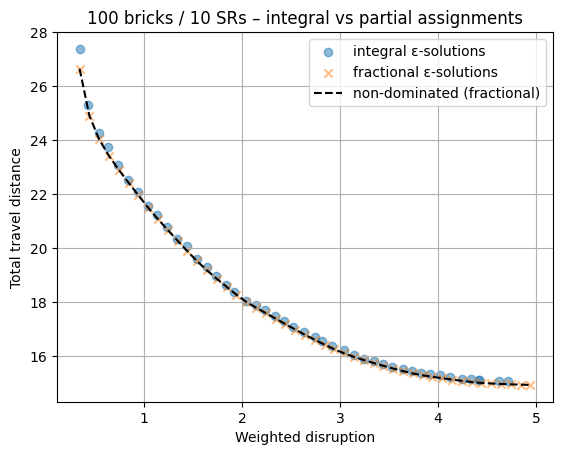

Minimal distance (integral model) : 15.082
Minimal distance (fractional model): 14.942


In [127]:

import matplotlib.pyplot as plt
from gurobipy import GRB

print("\n=== 2.2 100 bricks / 10 SRs – partial assignments allowed (x ∈ [0,1]) ===")

# Compute Pareto set with continuous variables
pareto_frac = epsilon_pareto(vtype=GRB.CONTINUOUS)
nd_frac = non_dominated(pareto_frac)

# Disruption range actually used on the ε-frontier (fractional case)
if pareto_frac:
    disr_vals_frac = [r for (r, _) in pareto_frac]
    disr_min_frontier = min(disr_vals_frac)
    disr_max_frontier = max(disr_vals_frac)
else:
    disr_min_frontier = disr_max_frontier = None

if pareto_frac and 'pareto_int' in globals():
    # Plot both sets on the same figure for an easy visual comparison
    disr_int, dist_int = zip(*pareto_int)
    disr_frac, dist_frac = zip(*pareto_frac)

    plt.figure()
    plt.scatter(disr_int, dist_int, alpha=0.5, label="integral ε‑solutions")
    plt.scatter(disr_frac, dist_frac, alpha=0.5, marker="x", label="fractional ε‑solutions")

    if nd_frac:
        disr_nd_f, dist_nd_f = zip(*nd_frac)
        plt.plot(disr_nd_f, dist_nd_f, "k--", label="non‑dominated (fractional)")

    plt.xlabel("Weighted disruption")
    plt.ylabel("Total travel distance")
    plt.title("100 bricks / 10 SRs – integral vs partial assignments")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Simple numeric comparison: best distance for low disruption levels
    best_int = min(dist_int)
    best_frac = min(dist_frac)
    print(f"Minimal distance (integral model) : {best_int:.3f}")
    print(f"Minimal distance (fractional model): {best_frac:.3f}")
else:
    print("Could not compute Pareto points for the fractional model.")



> **Remark.**  
> The continuous model is mainly a *theoretical* extension: in practice a brick is typically
> assigned to a single SR.  
> However, relaxing integrality is very helpful to understand the structure of the problem
> and to measure the gap between the fully integral solution and the (optimistic) case where
> bricks can be fractionally shared between several SRs.



=== 2.2 100 bricks / 10 SRs – fractional maps (min distance / min disruption) ===
[Fractional] Min distance : 14.942, disruption = 4.9426


C:\Users\simor\AppData\Local\Temp\ipykernel_22444\1516205160.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", Sales)


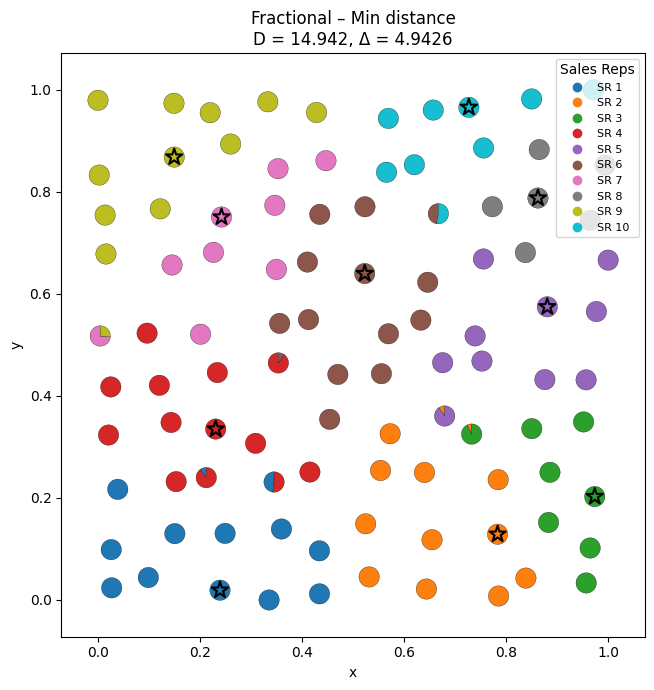

[Fractional] Min disruption : 0.3426, distance = 26.644


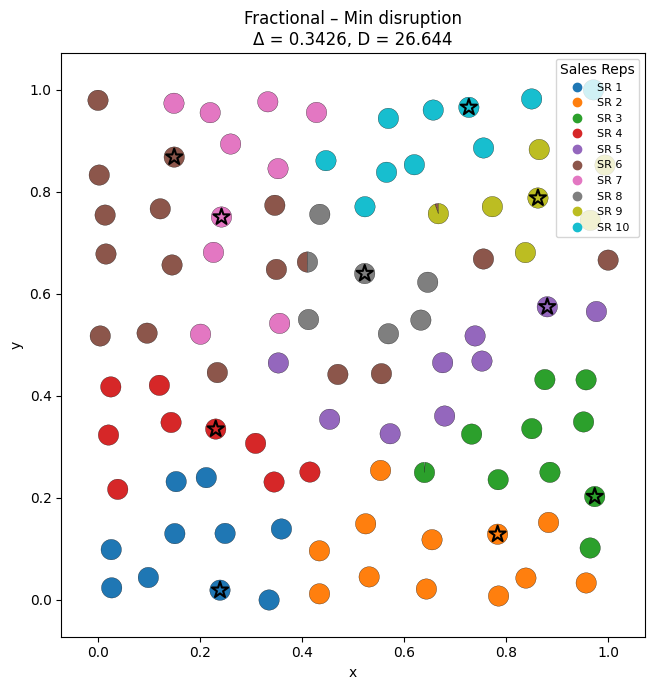

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Function for plotting fractional assignments as pie charts
# ------------------------------------------------------------
def plot_fractional_map_pies(x_sol, coords, office_indices, Sales, title=""):
    """
    x_sol : Gurobi tupledict x[j,i] from a CONTINUOUS model (fractional solution)
    coords: array (Bricks, 2)
    office_indices: list of brick indices hosting the SR offices
    Sales: number of SRs
    """
    Bricks = coords.shape[0]
    xs, ys = coords[:, 0], coords[:, 1]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # Pie chart radius
    x_range = xs.max() - xs.min()
    y_range = ys.max() - ys.min()
    R = 0.02 * max(x_range, y_range)

    cmap = plt.cm.get_cmap("tab10", Sales)
    colors = [cmap(j) for j in range(Sales)]

    # Background: light points
    ax.scatter(xs, ys, s=5, color="lightgrey", alpha=0.3, zorder=0)

    # Draw pies on each brick
    for i in range(Bricks):
        # Extract fractional assignments x[j,i] from the Gurobi variables
        fracs = np.array([x_sol[j, i].X for j in range(Sales)])
        total = fracs.sum()
        if total < 1e-6:
            continue
        fracs = fracs / total
        cx, cy = xs[i], ys[i]
        start_angle = 90.0  # start at top

        for j, f in enumerate(fracs):
            if f < 0.02:   # skip tiny slices
                continue
            theta = f * 360.0
            wedge = Wedge(
                (cx, cy),
                R,
                start_angle,
                start_angle + theta,
                facecolor=colors[j],
                edgecolor="black",
                linewidth=0.2,
                zorder=2,
            )
            ax.add_patch(wedge)
            start_angle += theta

    # Mark offices with stars
    for idx in office_indices:
        ax.scatter(
            coords[idx, 0],
            coords[idx, 1],
            marker="*",
            s=150,
            facecolor="none",
            edgecolor="black",
            linewidths=1.5,
            zorder=3,
        )

    # Legend
    legend_elems = [
        Line2D([0], [0], marker="o", linestyle="", color=colors[j], label=f"SR {j+1}")
        for j in range(Sales)
    ]
    ax.legend(handles=legend_elems, loc="upper right", fontsize=8, title="Sales Reps")

    plt.tight_layout()
    plt.show()


print("\n=== 2.2 100 bricks / 10 SRs – fractional maps (min distance / min disruption) ===")

# ------------------------------------------------------------
# (A) Fractional min-distance solution and map
# ------------------------------------------------------------
m_dist_f, x_dist_f, dist_expr_dist_f, disr_expr_dist_f = build_assignment_model(
    vtype=GRB.CONTINUOUS
)
# Enforce the same disruption cap as on the last ε-point of the frontier
if disr_max_frontier is not None:
    m_dist_f.addConstr(
        disr_expr_dist_f <= disr_max_frontier + 1e-6,
        name="eps_max_frontier_frac"
    )
m_dist_f.setObjective(dist_expr_dist_f, GRB.MINIMIZE)
m_dist_f.optimize()


if m_dist_f.status != GRB.OPTIMAL:
    raise RuntimeError("Distance-only fractional model infeasible.")

distance_min_frac = dist_expr_dist_f.getValue()
disruption_at_distance_min_frac = disr_expr_dist_f.getValue()

print(
    f"[Fractional] Min distance : {distance_min_frac:.3f}, "
    f"disruption = {disruption_at_distance_min_frac:.4f}"
)

plot_fractional_map_pies(
    x_sol=x_dist_f,
    coords=coords,
    office_indices=office_indices,
    Sales=Sales,
    title=(
        "Fractional – Min distance\n"
        f"D = {distance_min_frac:.3f}, Δ = {disruption_at_distance_min_frac:.4f}"
    ),
)

# ------------------------------------------------------------
# (B) Fractional min-disruption solution and map
# ------------------------------------------------------------
m_disr_f, x_disr_f, dist_expr_disr_f, disr_expr_disr_f = build_assignment_model(
    vtype=GRB.CONTINUOUS
)
# Keep disruption at its minimal value on the ε-frontier, then minimise distance
if disr_min_frontier is not None:
    m_disr_f.addConstr(
        disr_expr_disr_f <= disr_min_frontier + 1e-6,
        name="eps_min_frontier_frac"
    )
m_disr_f.setObjective(dist_expr_disr_f, GRB.MINIMIZE)
m_disr_f.optimize()

if m_disr_f.status != GRB.OPTIMAL:
    raise RuntimeError("Fractional frontier min-disruption model infeasible.")

disruption_min_frac = disr_expr_disr_f.getValue()
distance_at_disruption_min_frac = dist_expr_disr_f.getValue()


print(
    f"[Fractional] Min disruption : {disruption_min_frac:.4f}, "
    f"distance = {distance_at_disruption_min_frac:.3f}"
)

plot_fractional_map_pies(
    x_sol=x_disr_f,
    coords=coords,
    office_indices=office_indices,
    Sales=Sales,
    title=(
        "Fractional – Min disruption\n"
        f"Δ = {disruption_min_frac:.4f}, D = {distance_at_disruption_min_frac:.3f}"
    ),
)


### 2.3 Adding a new SR when demand increases by 25 %

We illustrate this scenario on the original 4×22 instance (4 SRs, 22 bricks) used in Step 1 and Step 2.1, not on the 100×10 instance.

We suppose that the demand (workload index) in **all bricks increases by 25 %**.  
To cope with this extra workload, Pfizer decides to hire **one additional sales representative**.

We keep the same structure of the model, but:
- workloads are multiplied by 1.25,
- we add a new SR with its own office,
- and we let the model decide the *best brick* where this new office should be located,
  assuming it must coincide with one of the existing bricks.

Instead of testing each possible office location one by one, we formulate everything in a **single MILP**:

- binary variables indicating **where** the new SR’s office is located (which brick),
- assignment variables describing **which bricks** are served by each existing SR and by the new SR,
- **workload-balance constraints** for all SRs (old and new),
- a binary disruption indicator for each brick, equal to 1 if its SR changes relative to the initial territories.

We then study **two extreme planning policies**:

1. a **travel-minimising plan**, where we minimise the *total distance* travelled by all SRs;  
2. a **stability-preserving plan**, where we minimise the *total disruption* (sum of workloads of bricks whose SR changes).

For each case we obtain:
- the optimal location of the new office,
- the new assignment of bricks to SRs,
- the corresponding distance and disruption levels.


In [129]:
# === Data for the 4×22 instance used in Step 2.3 ===
import pandas as pd
import numpy as np
from sklearn.manifold import MDS

# Load the 22×22 distance matrix between bricks (same file as in Step 3)
dist_df_22 = pd.read_excel("distances.xlsx", sheet_name=1, header=None).iloc[2:, 2:]
dist_df_22 = dist_df_22.reset_index(drop=True).reset_index(drop=True)
fullD_4x22 = dist_df_22.to_numpy(dtype=float)   # shape (22, 22)

num_bricks = fullD_4x22.shape[0]   # 22 bricks
B = num_bricks
J_old = 4                          # 4 existing SRs

# Workloads for the 4×22 instance (same as Step 1)
workloads = np.array([
    0.1609, 0.1164, 0.1026, 0.1516, 0.0939,
    0.1320, 0.0687, 0.0930, 0.2116, 0.2529,
    0.0868, 0.0828, 0.0975, 0.8177, 0.4115,
    0.3795, 0.0710, 0.0427, 0.1043, 0.0997,
    0.1698, 0.2531
], dtype=float)
assert abs(workloads.sum() - J_old) < 1e-6

# Offices are at bricks 4, 14, 16, 22 (1-based → 0-based)
office_indices_old_22 = [3, 13, 15, 21]
# Distance_oldSR[j, i] = distance between SR j office and brick i
Distance_oldSR = fullD_4x22[:, office_indices_old_22].T   # shape (4, 22)

# Rebuild 2D coordinates for plotting ONLY (MDS)
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
coords_22 = mds.fit_transform(fullD_4x22)


In [130]:
## Initial state : 
SR1_initial_state = [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
SR2_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
SR3_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0]
SR4_initial_state = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
SRs = [SR1_initial_state, SR2_initial_state, SR3_initial_state, SR4_initial_state]

# Initial SR (0-based) of each brick derived from initial territories
SR_initial_matrix = np.vstack([
    SR1_initial_state,
    SR2_initial_state,
    SR3_initial_state,
    SR4_initial_state,
])   # shape (4, 22)
initial_sr = np.argmax(SR_initial_matrix, axis=0)   # length 22



In [131]:
from gurobipy import Model, GRB, quicksum
import numpy as np

print("\n=== 2.3 Adding a new SR after a +25% demand increase (4x22 instance) ===")

# 1) Increase the workload uniformly by +25%
demand_factor = 1.25
workloads_plus = workloads * demand_factor
print(f"Total workload after +25% demand: {workloads_plus.sum():.3f}")

B = num_bricks      # number of bricks (22)
J_old = 4           # number of existing SRs (4)
min_w, max_w = WORKLOAD_BOUNDS


def build_plus1_model(log_output=True):
    """
    Build the 4×22 + 1 SR model.

    Returns:
        m  : Gurobi model
        x  : x[j,i] assignment of brick i to existing SR j (0..3)
        y  : y[k] = 1 if new SR office is at brick k
        z  : z[k,i] assignment of brick i to the new SR (office at k)
        u  : u[i] = 1 if brick i is disrupted
        total_distance : LinExpr for total travelled distance
        disruption_expr: LinExpr for total disruption (workload-weighted)
    """
    m = Model("Pfizer_4x22_plus1_office")
    m.Params.OutputFlag = 1 if log_output else 0

    # Decision variables
    x = m.addVars(J_old, B, vtype=GRB.BINARY, name="x")
    y = m.addVars(B, vtype=GRB.BINARY, name="y")
    z = m.addVars(B, B, vtype=GRB.BINARY, name="z")
    u = m.addVars(B, vtype=GRB.BINARY, name="u")

    # (1) Exactly one office for the new SR
    m.addConstr(y.sum() == 1, name="one_new_office")

    # (2) Link z and y : if y[k] = 0, no brick can be served from office k
    for k in range(B):
        for i in range(B):
            m.addConstr(z[k, i] <= y[k], name=f"link_z_y_{k}_{i}")

    # (3) Coverage: each brick assigned either to an old SR or to the new SR
    for i in range(B):
        m.addConstr(
            quicksum(x[j, i] for j in range(J_old)) +
            quicksum(z[k, i] for k in range(B)) == 1,
            name=f"cover_{i}"
        )

    # (4) Workload constraints
    # Existing SRs
    for j in range(J_old):
        load_j = quicksum(workloads_plus[i] * x[j, i] for i in range(B))
        m.addConstr(load_j >= min_w, name=f"load_old_min_{j}")
        m.addConstr(load_j <= max_w, name=f"load_old_max_{j}")

    # New SR
    load_new = quicksum(workloads_plus[i] * z[k, i] for k in range(B) for i in range(B))
    m.addConstr(load_new >= min_w, name="load_new_min")
    m.addConstr(load_new <= max_w, name="load_new_max")

    # (5) Disruption: u[i] = 1 if brick i is not assigned to its initial SR
    for i in range(B):
        j0 = initial_sr[i]  # initial SR for brick i

        # If assigned to any other old SR, u[i] must be 1
        for j in range(J_old):
            if j != j0:
                m.addConstr(u[i] >= x[j, i], name=f"disrupt_old_{i}_{j}")

        # If assigned to the new SR (any k), u[i] must be 1
        for k in range(B):
            m.addConstr(u[i] >= z[k, i], name=f"disrupt_new_{i}_{k}")

    # Weighted disruption (same as in Step 2.1)
    disruption_expr = quicksum(workloads_plus[i] * u[i] for i in range(B))

    # (6) Distance objective (old SRs + new SR)
    # distance for old SRs (using Distance_oldSR from Step 1)
    dist_old = quicksum(
        Distance_oldSR[j, i] * x[j, i]
        for j in range(J_old)
        for i in range(B)
    )

    # distance for the new SR (depends on chosen office k)
    dist_new = quicksum(
        float(fullD_4x22[k, i]) * z[k, i]
        for k in range(B)
        for i in range(B)
    )

    total_distance = dist_old + dist_new

    return m, x, y, z, u, total_distance, disruption_expr


# -------------------------------------------------------------
# Scenario 1 – Minimise total distance (travel-minimising plan)
# -------------------------------------------------------------
m, x, y, z, u, total_distance, disruption_expr = build_plus1_model(log_output=True)
m.setObjective(total_distance, GRB.MINIMIZE)
m.optimize()

if m.status != GRB.OPTIMAL:
    raise RuntimeError("No feasible solution for distance-minimising plan.")

chosen_k = max(range(B), key=lambda k: y[k].X)  # 0-based index of new office
best_dist = total_distance.getValue()
best_disr = disruption_expr.getValue()

print(f"\n[Scenario 1] Minimise distance:")
print(f"  New SR office location      : brick {chosen_k + 1}")
print(f"  Total distance (objective)  : {best_dist:.3f}")
print(f"  Total disruption (resulting): {best_disr:.3f}")


# -------------------------------------------------------------
# Scenario 2 – Minimise disruption (stability-preserving plan)
# -------------------------------------------------------------
m_disr, x_disr, y_disr, z_disr, u_disr, total_distance_disr, disruption_expr_disr = \
    build_plus1_model(log_output=False)

m_disr.setObjective(disruption_expr_disr, GRB.MINIMIZE)
m_disr.optimize()

if m_disr.status != GRB.OPTIMAL:
    raise RuntimeError("No feasible solution for disruption-minimising plan.")

chosen_k_disr = max(range(B), key=lambda k: y_disr[k].X)
best_disr_only = disruption_expr_disr.getValue()
best_dist_at_disr = total_distance_disr.getValue()

print(f"\n[Scenario 2] Minimise disruption:")
print(f"  New SR office location      : brick {chosen_k_disr + 1}")
print(f"  Total disruption (objective): {best_disr_only:.3f}")
print(f"  Total distance (resulting)  : {best_dist_at_disr:.3f}")



=== 2.3 Adding a new SR after a +25% demand increase (4x22 instance) ===
Total workload after +25% demand: 5.000
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900HX, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 1067 rows, 616 columns and 3806 nonzeros
Model fingerprint: 0x1f4ab610
Variable types: 0 continuous, 616 integer (616 binary)
Coefficient statistics:
  Matrix range     [5e-02, 1e+00]
  Objective range  [8e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e-01, 1e+00]
Found heuristic solution: objective 330.4547091
Presolve removed 554 rows and 22 columns
Presolve time: 0.02s
Presolved: 513 rows, 594 columns, 2728 nonzeros
Variable types: 0 continuous, 594 integer (594 binary)

Root relaxation: objective 1.092790e+02, 103 iterations, 0.00 seconds (0.00 work un


=== 2.3 – MAP WITH NEW SR (min distance plan) ===
New SR office (min distance) at brick 2


C:\Users\simor\AppData\Local\Temp\ipykernel_22444\3108856518.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", Sales_total)


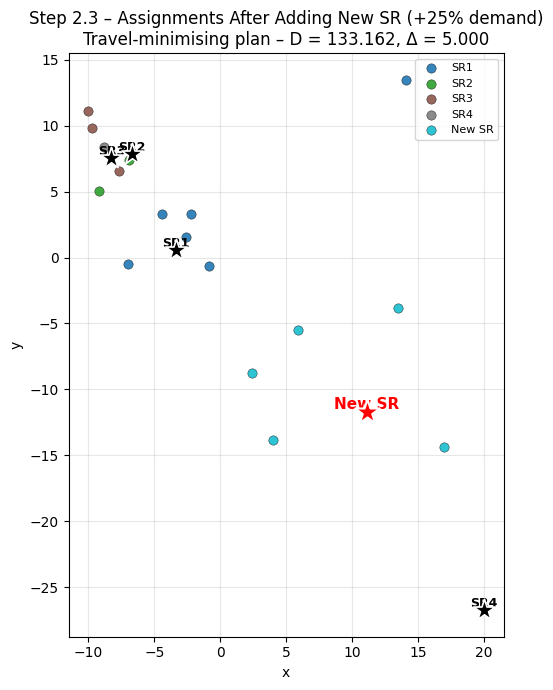


=== 2.3 – MAP WITH NEW SR (min disruption plan) ===
New SR office (min disruption) at brick 1


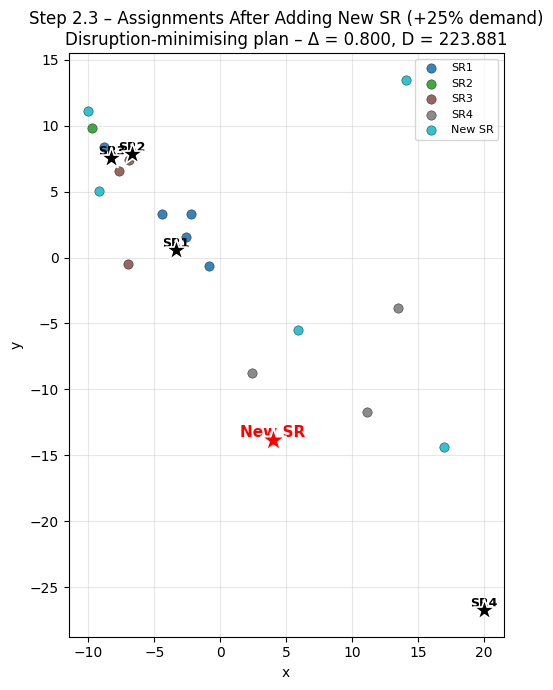

In [132]:
# ============================================================
# 2.3 – MAP OF THE OPTIMAL ASSIGNMENT AFTER ADDING NEW SR
#      (4 × 22 instance, using first 22 bricks)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def plot_map_newSR(title, assign, coords_local, office_indices_old, new_office_idx):
    """
    assign[i] = SR that serves brick i after optimization:
        - values in {0,1,2,3,4}
        - SR 0..3 = existing SRs
        - SR 4    = new SR
    coords_local: shape (22,2) for the 4×22 instance
    office_indices_old: list of 0-based brick indices for the 4 old offices
    new_office_idx: brick index (0-based) where the new SR office is located
    """
    Bricks_local = coords_local.shape[0]
    Sales_total = 5  # 4 existing + 1 new
    cmap = plt.cm.get_cmap("tab10", Sales_total)

    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    # Bricks colored by SR
    for j in range(Sales_total):
        mask = (assign == j)
        if np.any(mask):
            plt.scatter(
                coords_local[mask, 0],
                coords_local[mask, 1],
                s=45,
                color=cmap(j),
                edgecolors="black",
                linewidths=0.3,
                alpha=0.9,
                label=f"SR{j+1}" if j < 4 else "New SR",
                zorder=2,
            )

    # Old SR offices (black stars)
    for j, idx in enumerate(office_indices_old):
        x_off, y_off = coords_local[idx]
        plt.scatter(
            x_off, y_off,
            marker="*",
            s=260,
            color="black",
            edgecolors="white",
            linewidths=1.2,
            zorder=4,
        )
        plt.text(
            x_off, y_off,
            f"SR{j+1}",
            fontsize=9,
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    # New SR office (big red star)
    x_new, y_new = coords_local[new_office_idx]
    plt.scatter(
        x_new, y_new,
        marker="*",
        s=350,
        color="red",
        edgecolors="white",
        linewidths=1.5,
        zorder=5,
    )
    plt.text(
        x_new, y_new,
        "New SR",
        fontsize=11,
        color="red",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

    ax.set_aspect("equal", "box")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# 0-based indices of the 4 old offices (bricks 4, 14, 16, 22)
office_indices_old_22 = [3, 13, 15, 21]

print("\n=== 2.3 – MAP WITH NEW SR (min distance plan) ===")

# ---------- Scenario 1: min distance ----------
# New office location (from y[k]) for the distance-minimising solution
chosen_k_dist = max(range(B), key=lambda k: y[k].X)
new_office_idx_dist = chosen_k_dist
print(f"New SR office (min distance) at brick {new_office_idx_dist + 1}")

# Build final assignment for this scenario
assign_final_dist = np.zeros(B, dtype=int)
for i in range(B):
    served_by_new = any(z[k, i].X > 0.5 for k in range(B))
    if served_by_new:
        assign_final_dist[i] = 4
    else:
        for j in range(J_old):
            if x[j, i].X > 0.5:
                assign_final_dist[i] = j
                break

plot_map_newSR(
    title=(
        "Step 2.3 – Assignments After Adding New SR (+25% demand)\n"
        f"Travel-minimising plan – D = {total_distance.getValue():.3f}, "
        f"Δ = {disruption_expr.getValue():.3f}"
    ),
    assign=assign_final_dist,
    coords_local=coords_22,
    office_indices_old=office_indices_old_22,
    new_office_idx=new_office_idx_dist,
)

print("\n=== 2.3 – MAP WITH NEW SR (min disruption plan) ===")

# ---------- Scenario 2: min disruption ----------
chosen_k_disr = max(range(B), key=lambda k: y_disr[k].X)
new_office_idx_disr = chosen_k_disr
print(f"New SR office (min disruption) at brick {new_office_idx_disr + 1}")

assign_final_disr = np.zeros(B, dtype=int)
for i in range(B):
    served_by_new_disr = any(z_disr[k, i].X > 0.5 for k in range(B))
    if served_by_new_disr:
        assign_final_disr[i] = 4
    else:
        for j in range(J_old):
            if x_disr[j, i].X > 0.5:
                assign_final_disr[i] = j
                break

plot_map_newSR(
    title=(
        "Step 2.3 – Assignments After Adding New SR (+25% demand)\n"
        f"Disruption-minimising plan – Δ = {disruption_expr_disr.getValue():.3f}, "
        f"D = {total_distance_disr.getValue():.3f}"
    ),
    assign=assign_final_disr,
    coords_local=coords_22,
    office_indices_old=office_indices_old_22,
    new_office_idx=new_office_idx_disr,
)


In [133]:
# ============================================================
# 2.3 – Assignment Breakdown + TOTAL DISTANCE
# ============================================================

print("\n=== 2.3 – Assignment Breakdown (min distance plan) ===")

# --- Helpers reused for both scenarios ---

def workload_of(brick_list):
    """Total workload (after +25%) of a list of 1-based bricks."""
    return sum(workloads_plus[i - 1] for i in brick_list)

def distance_of_old_SR(j, brick_list):
    """Distance accumulated by old SR j (using Step 1 distances)."""
    return sum(Distance_oldSR[j, i - 1] for i in brick_list)

def distance_of_new_SR(new_office_idx, brick_list):
    """Distance accumulated by new SR (office at brick k)."""
    return sum(fullD_4x22[new_office_idx, i - 1] for i in brick_list)


# ---------- Scenario 1: min distance ----------
SR_assignments_dist = {j: [] for j in range(J_old)}  # SR 0..3
SR_assignments_dist[4] = []                          # new SR

for i in range(B):
    if assign_final_dist[i] == 4:
        SR_assignments_dist[4].append(i + 1)
    else:
        SR_assignments_dist[assign_final_dist[i]].append(i + 1)

total_distance_sum_dist = 0.0

for j in range(J_old):
    bricks = SR_assignments_dist[j]
    w = workload_of(bricks)
    d = distance_of_old_SR(j, bricks)
    total_distance_sum_dist += d

    print(f"\nSR {j+1} (old):")
    print(f"  Bricks assigned ({len(bricks)}): {bricks}")
    print(f"  Workload = {w:.3f}")
    print(f"  Distance = {d:.3f}")

new_bricks_dist = SR_assignments_dist[4]
w_new_dist = workload_of(new_bricks_dist)
d_new_dist = distance_of_new_SR(new_office_idx_dist, new_bricks_dist)
total_distance_sum_dist += d_new_dist

print("\nNEW SR:")
print(f"  Bricks assigned ({len(new_bricks_dist)}): {new_bricks_dist}")
print(f"  Workload = {w_new_dist:.3f}")
print(f"  Distance = {d_new_dist:.3f}")

print("\n----------------------------------------")
print(f"Total distance (sum of all SRs): {total_distance_sum_dist:.3f}")
print(f"Model objective value           : {total_distance.getValue():.3f}")
print("----------------------------------------")
if abs(total_distance_sum_dist - total_distance.getValue()) < 1e-6:
    print("Total distance matches the model objective.")
else:
    print("WARNING: mismatch detected for min-distance plan.")


# ---------- Scenario 2: min disruption ----------
print("\n=== 2.3 – Assignment Breakdown (min disruption plan) ===")

SR_assignments_disr = {j: [] for j in range(J_old)}
SR_assignments_disr[4] = []

for i in range(B):
    if assign_final_disr[i] == 4:
        SR_assignments_disr[4].append(i + 1)
    else:
        SR_assignments_disr[assign_final_disr[i]].append(i + 1)

total_distance_sum_disr = 0.0

for j in range(J_old):
    bricks = SR_assignments_disr[j]
    w = workload_of(bricks)
    d = distance_of_old_SR(j, bricks)
    total_distance_sum_disr += d

    print(f"\nSR {j+1} (old):")
    print(f"  Bricks assigned ({len(bricks)}): {bricks}")
    print(f"  Workload = {w:.3f}")
    print(f"  Distance = {d:.3f}")

new_bricks_disr = SR_assignments_disr[4]
w_new_disr = workload_of(new_bricks_disr)
d_new_disr = distance_of_new_SR(new_office_idx_disr, new_bricks_disr)
total_distance_sum_disr += d_new_disr

print("\nNEW SR:")
print(f"  Bricks assigned ({len(new_bricks_disr)}): {new_bricks_disr}")
print(f"  Workload = {w_new_disr:.3f}")
print(f"  Distance = {d_new_disr:.3f}")

print("\n----------------------------------------")
print(f"Total distance (sum of all SRs): {total_distance_sum_disr:.3f}")
print(f"Model objective value           : {total_distance_disr.getValue():.3f}")
print("----------------------------------------")
if abs(total_distance_sum_disr - total_distance_disr.getValue()) < 1e-6:
    print("Total distance matches the model objective (min disruption plan).")
else:
    print("WARNING: mismatch detected for min-disruption plan.")



=== 2.3 – Assignment Breakdown (min distance plan) ===

SR 1 (old):
  Bricks assigned (7): [4, 5, 6, 7, 8, 9, 12]
  Workload = 1.042
  Distance = 35.751

SR 2 (old):
  Bricks assigned (3): [13, 14, 18]
  Workload = 1.197
  Distance = 4.051

SR 3 (old):
  Bricks assigned (4): [10, 11, 16, 17]
  Workload = 0.988
  Distance = 8.416

SR 4 (old):
  Bricks assigned (2): [15, 22]
  Workload = 0.831
  Distance = 45.428

NEW SR:
  Bricks assigned (6): [1, 2, 3, 19, 20, 21]
  Workload = 0.942
  Distance = 39.517

----------------------------------------
Total distance (sum of all SRs): 133.162
Model objective value           : 133.162
----------------------------------------
Total distance matches the model objective.

=== 2.3 – Assignment Breakdown (min disruption plan) ===

SR 1 (old):
  Bricks assigned (6): [4, 5, 6, 7, 8, 15]
  Workload = 1.188
  Distance = 19.296

SR 2 (old):
  Bricks assigned (2): [11, 14]
  Workload = 1.131
  Distance = 3.506

SR 3 (old):
  Bricks assigned (4): [9, 16, 1